# 01 — Data collection: Truth Social posts

Doel: lokale dump opbouwen van Donald Trump's Truth Social posts sinds februari 2022.

**Belangrijk:** we scrapen Truth Social niet rechtstreeks. We werken uitsluitend met
publiek beschikbare archieven/mirrors.

**Kanalen, in volgorde van voorkeur:**

| Kanaal | Pro | Con |
|---|---|---|
| Lokale Kaggle-archive (CSV) | Stabiel, geen auth, volledige history | Niet altijd up-to-date |
| trumpstruth.org RSS (`scrape_trumpstruth_rss.py`) | Live aanvulling, geen auth | Externe mirror, beperkte metadata |
| Synthetic fallback | Werkt offline | Niet bruikbaar voor finale resultaten |

**Strategie**: laad de complete Kaggle-dump (stabiel) voor de bulk historische data,
en vul de laatste dagen aan via de trumpstruth.org RSS-scraper
(`src/data/scrape_trumpstruth_rss.py`).

De loader-functie `fetch_posts_archive()` in `src/data/collect_truthsocial.py`
normaliseert het Kaggle-schema (`like_count`, `retruth_count`, `reply_count`, …)
naar `favorites`, `reposts`, `replies`.

In [1]:
%load_ext autoreload
%autoreload 2

import sys
import warnings
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.data.collect_truthsocial import fetch_posts_archive

sns.set_theme(style="whitegrid", context="notebook")
warnings.filterwarnings("ignore", category=FutureWarning)

print(f"pandas={pd.__version__}, numpy={np.__version__}")

pandas=3.0.2, numpy=2.4.4


## Optie A — live aanvulling via trumpstruth.org RSS

De historische bulk komt uit het Kaggle-archief (zie orchestrator hieronder). Voor de
meest recente posts gebruiken we de RSS-feed van trumpstruth.org via een aparte module:

    python -m src.data.scrape_trumpstruth_rss --start 2026-02-28

Geen authenticatie, geen Truth Social login nodig. De output (`posts_live.parquet`) is
schema-compatibel met `posts.parquet` en wordt in de event-study notebooks samengevoegd
met het archief.

## Optie C — synthetic fallback (offline testing)

Voor offline iteratie en als de echte source faalt. Niet bruikbaar voor finale resultaten.


In [2]:
TOPIC_VOCAB = {
    "trade": ["tariffs are working great", "China is paying us billions in tariffs",
              "the trade deal will be massive", "we need fair trade not free trade"],
    "fed": ["the Fed should cut rates immediately", "Powell is way behind the curve",
            "interest rates are too high", "we have no inflation thanks to my policies"],
    "energy": ["drill baby drill", "we need cheap energy for American families",
               "Saudi Arabia must increase oil production", "OPEC playing games with oil prices"],
    "election": ["the polls look fantastic", "tremendous rally tonight massive crowds",
                 "the radical left is destroying our country", "Make America Great Again"],
    "economy": ["best economy in history", "stock market hitting all time highs",
                "jobs jobs jobs", "GDP growth is incredible", "inflation is being defeated"],
    "media": ["fake news media wont report this", "CNN ratings have collapsed",
              "the failing New York Times strikes again", "media is the enemy of the people"],
}


def synthesize_posts(n_days: int = 1500, posts_per_day_lambda: float = 12.0,
                     start_date: str = "2022-02-21", seed: int = 42) -> pd.DataFrame:
    """Plausibele posts genereren — alleen voor offline testing."""
    rng = np.random.default_rng(seed)
    start = pd.Timestamp(start_date, tz="UTC")
    rows = []
    for day_offset in range(n_days):
        date = start + pd.Timedelta(days=day_offset)
        n_posts = rng.poisson(posts_per_day_lambda)
        for _ in range(n_posts):
            topic = rng.choice(list(TOPIC_VOCAB.keys()))
            phrases = rng.choice(TOPIC_VOCAB[topic], size=rng.integers(1, 4), replace=True)
            text = ". ".join(phrases).capitalize() + "!"
            hour = int(rng.integers(0, 24))
            timestamp = date.replace(hour=hour, minute=int(rng.integers(0, 60)))
            rows.append({"post_id": f"synth_{len(rows):07d}", "timestamp_utc": timestamp,
                         "text": text, "favorites": int(rng.lognormal(9, 1.5)),
                         "reposts": int(rng.lognormal(7, 1.5)), "replies": int(rng.lognormal(7, 1.5)),
                         "url": f"https://example.synthetic/post/{len(rows)}"})
    df = pd.DataFrame(rows)
    df.attrs["source"] = "synthetic"
    return df.sort_values("timestamp_utc").reset_index(drop=True)

## Main: collection orchestrator

Probeer in deze volgorde: Kaggle-archive → synthetic fallback.
De live-aanvulling via trumpstruth.org RSS draait apart (zie Optie A) en levert
`posts_live.parquet`.

In [3]:
ARCHIVE_PATH = Path("../data/raw/trump_truth_archive.csv")


def collect() -> pd.DataFrame:
    if ARCHIVE_PATH.exists() and ARCHIVE_PATH.stat().st_size > 1000:
        print(f"→ Loading from archive: {ARCHIVE_PATH}")
        df = fetch_posts_archive(ARCHIVE_PATH)
        df.attrs["source"] = "kaggle_archive"
        return df

    print("→ Geen archive beschikbaar — fallback op synthetic data.")
    return synthesize_posts()


posts = collect()
print(f"\nSource:     {posts.attrs.get('source', 'unknown')}")
print(f"Shape:      {posts.shape}")

→ Loading from archive: ../data/raw/trump_truth_archive.csv

Source:     kaggle_archive
Shape:      (26819, 40)


/Users/quintenfriederichs/code/truthsocial-marketimpact/src/data/collect_truthsocial.py:44: DtypeWarning: Columns (0: is_policy_related) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(path)


## Data quality checks


In [4]:
print("--- Dtypes ---")
print(posts.dtypes)
print()
print("--- Missing values per kolom ---")
print(posts.isna().sum())
print()
print("--- Duplicate post_ids ---")
print(f"  {posts['post_id'].duplicated().sum()}")
print()
print("--- Timestamps monotonic? ---")
print(f"  {posts['timestamp_utc'].is_monotonic_increasing}")

--- Dtypes ---
post_id                                  int64
timestamp_utc              datetime64[us, UTC]
text                                       str
url                                        str
reposts                                  int64
favorites                                int64
replies                                  int64
engagement_ratio                       float64
is_retruth                                bool
hour_of_day                              int64
day_of_week                                str
is_weekend                                bool
days_since_last_post                   float64
sentiment_score                        float64
sentiment_label                            str
emotion                                    str
readability_score                      float64
word_count                             float64
cap_ratio                              float64
all_caps_word_count                    float64
exclamation_count                      float6

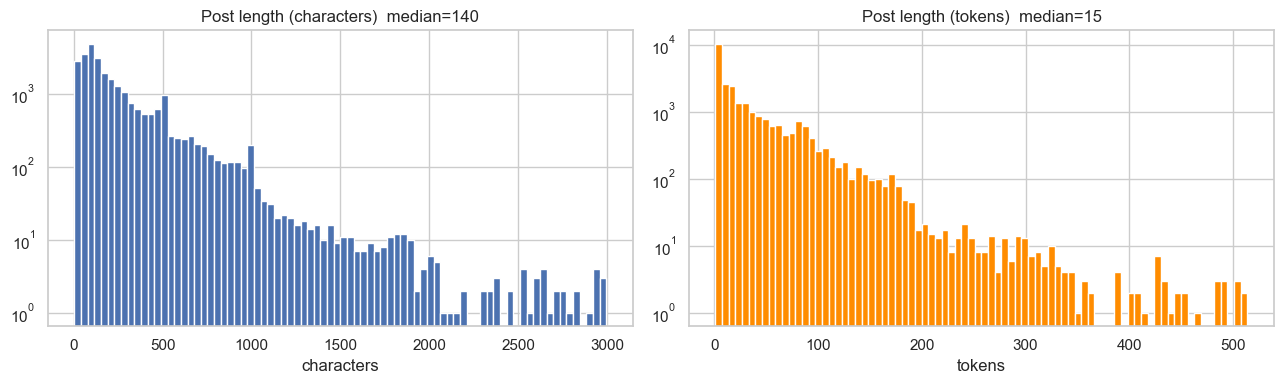

Posts < 5 tokens:   8,908  (33.2%)
Posts > 100 tokens: 2,174  (8.1%)


In [5]:
# Tekstlengte distributie (na het droppen van text=NaN posts in de loader)
posts["n_chars"] = posts["text"].str.len()
posts["n_tokens"] = posts["text"].str.split().str.len()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(posts["n_chars"], bins=80, edgecolor="white")
axes[0].set_title(f"Post length (characters)  median={posts['n_chars'].median():.0f}")
axes[0].set_xlabel("characters")
axes[0].set_yscale("log")

axes[1].hist(posts["n_tokens"], bins=80, edgecolor="white", color="darkorange")
axes[1].set_title(f"Post length (tokens)  median={posts['n_tokens'].median():.0f}")
axes[1].set_xlabel("tokens")
axes[1].set_yscale("log")
fig.tight_layout()
plt.show()

print(f"Posts < 5 tokens:   {(posts['n_tokens'] < 5).sum():,}  ({(posts['n_tokens'] < 5).mean()*100:.1f}%)")
print(f"Posts > 100 tokens: {(posts['n_tokens'] > 100).sum():,}  ({(posts['n_tokens'] > 100).mean()*100:.1f}%)")

## Volume over tijd


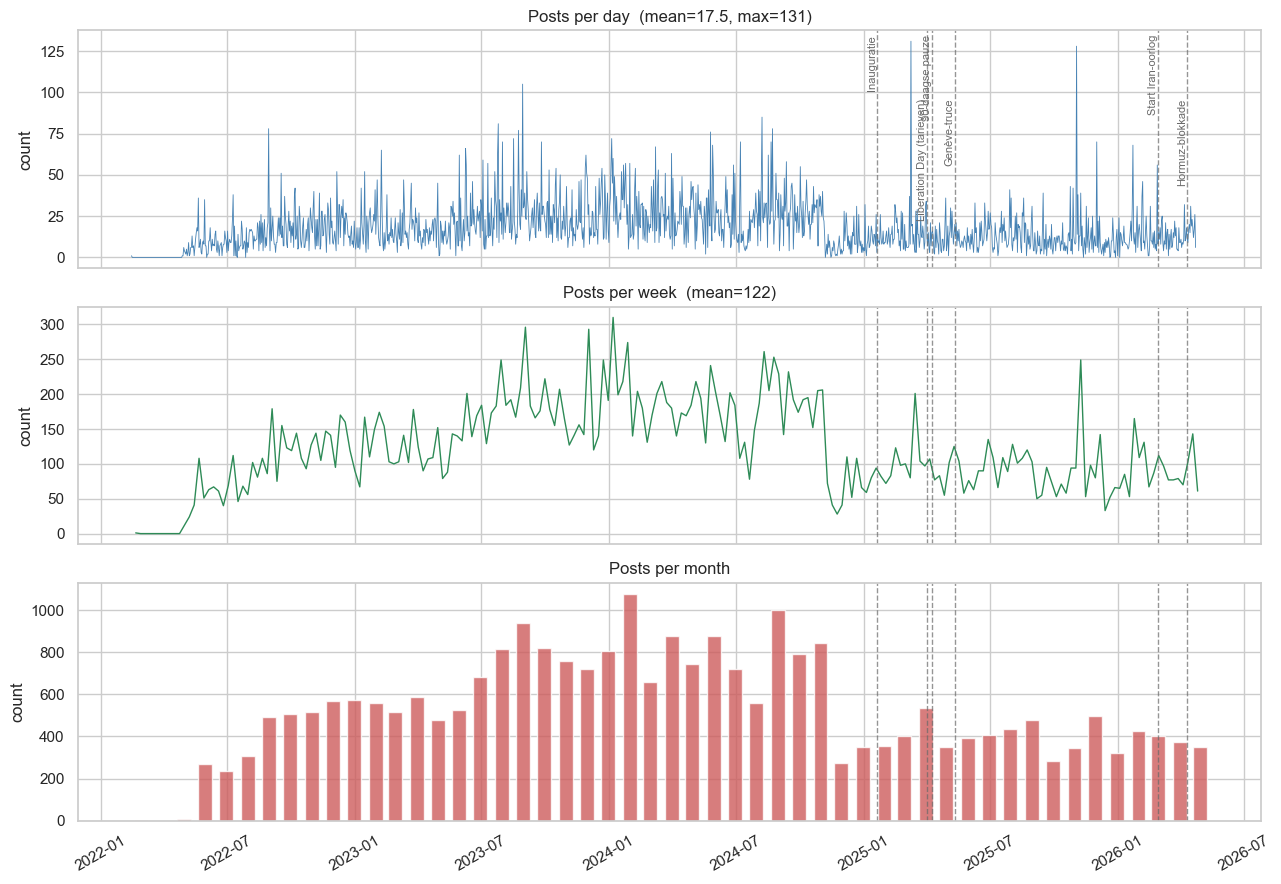

In [6]:
posts_per_day = posts.set_index("timestamp_utc").resample("D").size().rename("n_posts")
posts_per_week = posts.set_index("timestamp_utc").resample("W").size().rename("n_posts")
posts_per_month = posts.set_index("timestamp_utc").resample("ME").size().rename("n_posts")

# Belangrijke gebeurtenissen om te markeren (datum in UTC -> label)
EVENTS = {
    "2025-01-20": "Inauguratie",
    "2025-04-02": "Liberation Day (tarieven)",
    "2025-04-09": "90-daagse pauze",
    "2025-05-12": "Gen\u00e8ve-truce",
    "2026-02-28": "Start Iran-oorlog",
    "2026-04-11": "Hormuz-blokkade",
}

fig, axes = plt.subplots(3, 1, figsize=(13, 9), sharex=True)
axes[0].plot(posts_per_day.index, posts_per_day.values, linewidth=0.6, color="steelblue")
axes[0].set_title(f"Posts per day  (mean={posts_per_day.mean():.1f}, max={posts_per_day.max()})")
axes[0].set_ylabel("count")

axes[1].plot(posts_per_week.index, posts_per_week.values, linewidth=1.0, color="seagreen")
axes[1].set_title(f"Posts per week  (mean={posts_per_week.mean():.0f})")
axes[1].set_ylabel("count")

axes[2].bar(posts_per_month.index, posts_per_month.values, width=20, color="indianred", alpha=0.8)
axes[2].set_title("Posts per month")
axes[2].set_ylabel("count")
axes[2].tick_params(axis="x", rotation=30)

# Event-markers op alle subplots; labels enkel op de bovenste (afwisselende hoogte i.v.m. overlap)
data_min, data_max = posts_per_day.index.min(), posts_per_day.index.max()
for ax in axes:
    for d in EVENTS:
        ts = pd.Timestamp(d, tz="UTC")
        if data_min <= ts <= data_max:
            ax.axvline(ts, color="dimgray", linestyle="--", linewidth=1, alpha=0.7)

ymax = axes[0].get_ylim()[1]
for i, (d, label) in enumerate(EVENTS.items()):
    ts = pd.Timestamp(d, tz="UTC")
    if data_min <= ts <= data_max:
        y = ymax * (0.98 if i % 2 == 0 else 0.70)
        axes[0].text(ts, y, label, rotation=90, va="top", ha="right",
                     fontsize=8, color="dimgray")

fig.tight_layout()
plt.show()

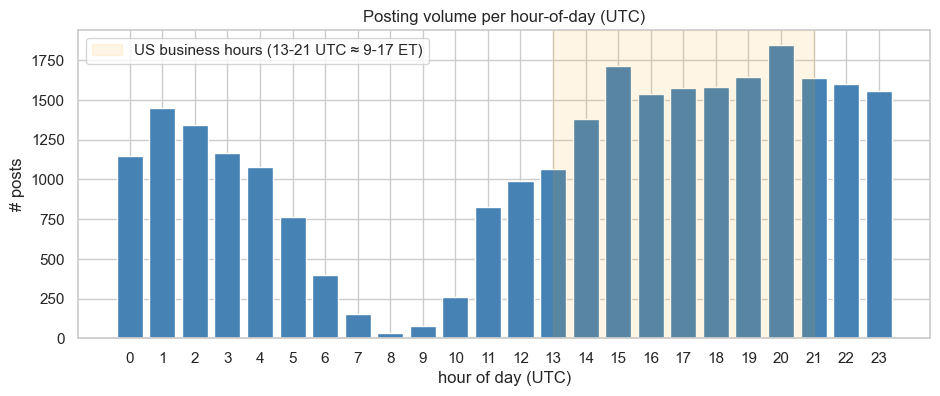

In [7]:
# Posting hour distributie (UTC)
hour_dist = posts["timestamp_utc"].dt.hour.value_counts().sort_index()

fig, ax = plt.subplots(figsize=(11, 4))
ax.bar(hour_dist.index, hour_dist.values, color="steelblue", edgecolor="white")
ax.set_title("Posting volume per hour-of-day (UTC)")
ax.set_xlabel("hour of day (UTC)")
ax.set_ylabel("# posts")
ax.set_xticks(range(0, 24))
ax.axvspan(13, 21, alpha=0.1, color="orange", label="US business hours (13-21 UTC ≈ 9-17 ET)")
ax.legend()
plt.show()

## Vocabulary preview

Top-30 woorden na simpele stopwords-filter. Niet voor productie — voor de echte
TF-IDF zie notebook 04.


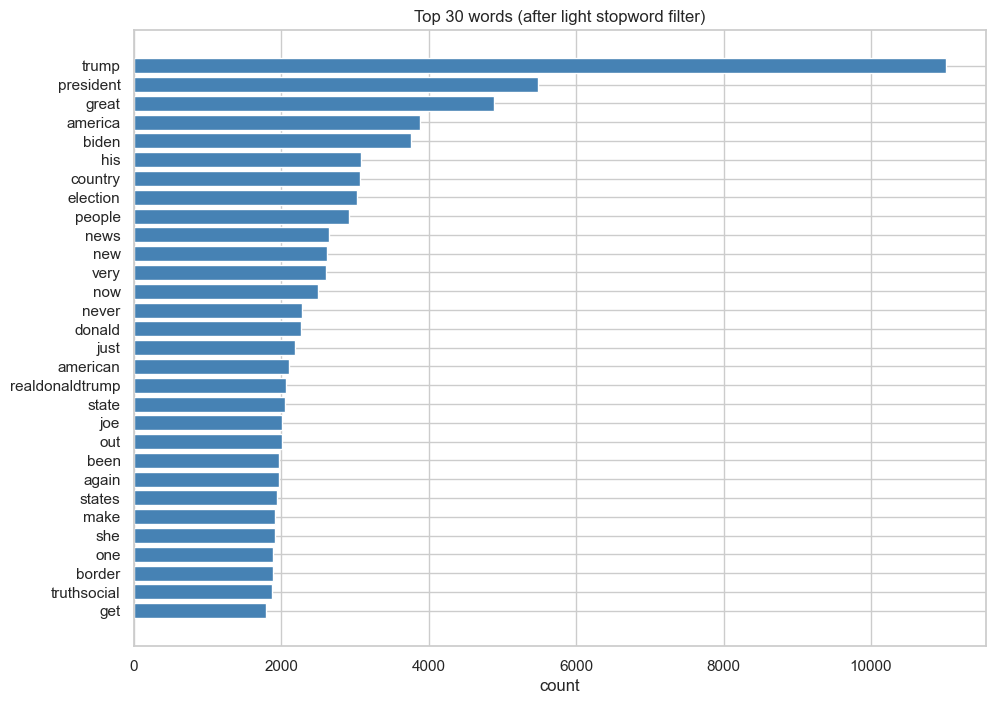

,word,count
0,trump,11011
1,president,5479
2,great,4892
3,america,3880
4,biden,3757
5,his,3080
6,country,3073
7,election,3024
8,people,2924
9,news,2651


In [8]:
STOPWORDS = {
    "a", "an", "and", "are", "as", "at", "be", "by", "for", "from", "has", "have",
    "i", "in", "is", "it", "its", "of", "on", "or", "our", "so", "that", "the",
    "this", "to", "was", "were", "will", "with", "you", "your", "we", "us", "they",
    "them", "their", "but", "not", "no", "do", "does", "did", "if", "all", "my",
    "me", "im", "ive", "youre", "thats", "its", "dont", "wont", "would", "could",
    "should", "what", "when", "where", "who", "how", "which", "than", "then", "https","com","www"
}

from collections import Counter
import re

words = []
for t in posts["text"].str.lower():
    tokens = re.findall(r"[a-z]+", str(t))
    words.extend(w for w in tokens if w not in STOPWORDS and len(w) > 2)

word_counts = Counter(words)
top30 = word_counts.most_common(30)
top_df = pd.DataFrame(top30, columns=["word", "count"])

fig, ax = plt.subplots(figsize=(11, 8))
ax.barh(top_df["word"][::-1], top_df["count"][::-1], color="steelblue")
ax.set_title("Top 30 words (after light stopword filter)")
ax.set_xlabel("count")
plt.show()
top_df.head(15)

## Save processed


In [9]:
out_path = Path("../data/raw/posts.parquet")
out_path.parent.mkdir(parents=True, exist_ok=True)

# Drop temporary EDA columns
to_save = posts.drop(columns=["n_chars", "n_tokens"], errors="ignore")
# Keep only canonical schema kolommen (eventuele bonus Kaggle features droppen voor cleanliness)
canonical = ["post_id", "timestamp_utc", "text", "favorites", "reposts", "replies", "url"]
to_save = to_save[[c for c in canonical if c in to_save.columns]]

to_save.to_parquet(out_path, index=False)
print(f"Wrote {len(to_save):,} posts to {out_path.resolve()}")
print(f"Source: {posts.attrs.get('source', 'unknown')}")
print(f"Columns: {list(to_save.columns)}")

Wrote 26,819 posts to /Users/quintenfriederichs/code/truthsocial-marketimpact/data/raw/posts.parquet
Source: kaggle_archive
Columns: ['post_id', 'timestamp_utc', 'text', 'favorites', 'reposts', 'replies', 'url']
